In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn 
import warnings
warnings.filterwarnings('ignore')

In [107]:
df = pd.read_csv('indicators_npl.csv')
df.head()

,Country Name,Country ISO3,Year,Indicator Name,Indicator Code,Value
0,Nepal,NPL,1983,Fertilizer consumption (% of fertilizer produc...,AG.CON.FERT.PT.ZS,129.065744
1,Nepal,NPL,2023,Fertilizer consumption (kilograms per hectare ...,AG.CON.FERT.ZS,67.842887
2,Nepal,NPL,2022,Fertilizer consumption (kilograms per hectare ...,AG.CON.FERT.ZS,67.842887
3,Nepal,NPL,2021,Fertilizer consumption (kilograms per hectare ...,AG.CON.FERT.ZS,112.611046
4,Nepal,NPL,2020,Fertilizer consumption (kilograms per hectare ...,AG.CON.FERT.ZS,115.325690


In [108]:
df['Country Name'].nunique()

1

In [109]:
df['Country ISO3'].nunique()

1

In [110]:
df.isna().sum()

Country Name      0
Country ISO3      0
Year              0
Indicator Name    0
Indicator Code    0
Value             0
dtype: int64

In [111]:
df.duplicated().sum()

np.int64(16885)

In [112]:
df[df.duplicated()]

,Country Name,Country ISO3,Year,Indicator Name,Indicator Code,Value
5359,Nepal,NPL,2023,"Grants, excluding technical cooperation (BoP, ...",BX.GRT.EXTA.CD.WD,4.889788e+08
5360,Nepal,NPL,2022,"Grants, excluding technical cooperation (BoP, ...",BX.GRT.EXTA.CD.WD,4.725397e+08
5361,Nepal,NPL,2021,"Grants, excluding technical cooperation (BoP, ...",BX.GRT.EXTA.CD.WD,6.719231e+08
5362,Nepal,NPL,2020,"Grants, excluding technical cooperation (BoP, ...",BX.GRT.EXTA.CD.WD,5.588216e+08
5363,Nepal,NPL,2019,"Grants, excluding technical cooperation (BoP, ...",BX.GRT.EXTA.CD.WD,5.657372e+08
...,...,...,...,...,...,...
73842,Nepal,NPL,1980,Travel services (% of commercial service exports),TX.VAL.TRVL.ZS.WT,5.367200e+01
73843,Nepal,NPL,1979,Travel services (% of commercial service exports),TX.VAL.TRVL.ZS.WT,5.002788e+01
73844,Nepal,NPL,1978,Travel services (% of commercial service exports),TX.VAL.TRVL.ZS.WT,4.577426e+01
73845,Nepal,NPL,1977,Travel services (% of commercial service exports),TX.VAL.TRVL.ZS.WT,4.545203e+01


In [113]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73847 entries, 0 to 73846
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    73847 non-null  object 
 1   Country ISO3    73847 non-null  object 
 2   Year            73847 non-null  int64  
 3   Indicator Name  73847 non-null  object 
 4   Indicator Code  73847 non-null  object 
 5   Value           73847 non-null  float64
dtypes: float64(1), int64(1), object(4)
memory usage: 3.4+ MB


In [114]:
df = df.drop_duplicates()

In [115]:
df.head()

,Country Name,Country ISO3,Year,Indicator Name,Indicator Code,Value
0,Nepal,NPL,1983,Fertilizer consumption (% of fertilizer produc...,AG.CON.FERT.PT.ZS,129.065744
1,Nepal,NPL,2023,Fertilizer consumption (kilograms per hectare ...,AG.CON.FERT.ZS,67.842887
2,Nepal,NPL,2022,Fertilizer consumption (kilograms per hectare ...,AG.CON.FERT.ZS,67.842887
3,Nepal,NPL,2021,Fertilizer consumption (kilograms per hectare ...,AG.CON.FERT.ZS,112.611046
4,Nepal,NPL,2020,Fertilizer consumption (kilograms per hectare ...,AG.CON.FERT.ZS,115.325690


In [116]:
df['Indicator Name'].unique()

array(['Fertilizer consumption (% of fertilizer production)',
       'Fertilizer consumption (kilograms per hectare of arable land)',
       'Agricultural land (sq. km)', ...,
       'Public and publicly guaranteed debt service (% of exports of goods, services and primary income)',
       'Multilateral debt service (TDS, current US$)',
       'Multilateral debt service (% of public and publicly guaranteed debt service)'],
      shape=(3361,), dtype=object)

In [117]:
gdp_indicators = df[df['Indicator Name'].str.contains('GDP', na=False)]['Indicator Name'].unique()
gdp_indicators.sort()
gdp_indicators

array(['Agriculture, forestry, and fishing, value added (% of GDP)',
       'Bank deposits to GDP (%)', 'Broad money (% of GDP)',
       'Carbon intensity of GDP (kg CO2e per 2021 PPP $ of GDP)',
       'Carbon intensity of GDP (kg CO2e per constant 2015 US$ of GDP)',
       'Central bank assets to GDP (%)',
       'Central government debt, total (% of GDP)',
       'Claims on central government, etc. (% GDP)',
       'Coal rents (% of GDP)',
       'Consolidated foreign claims of BIS reporting banks to GDP (%)',
       'Credit to government and state-owned enterprises to GDP (%)',
       'Current account balance (% of GDP)',
       'Current health expenditure (% of GDP)',
       "Deposit money banks'' assets to GDP (%)",
       'Discrepancy in expenditure estimate of GDP (constant LCU)',
       'Discrepancy in expenditure estimate of GDP (current LCU)',
       'Domestic credit to private sector (% of GDP)',
       'Domestic credit to private sector by banks (% of GDP)',
       'Domest

In [118]:

key_indicators = [
    'GDP growth (annual %)',
    'Inflation, consumer prices (annual %)',
    'Agriculture, forestry, and fishing, value added (% of GDP)',
    'Exports of goods and services (% of GDP)',
    'Imports of goods and services (% of GDP)'
]


df_filtered = df[df['Indicator Name'].isin(key_indicators)]
df_filtered.head()



,Country Name,Country ISO3,Year,Indicator Name,Indicator Code,Value
1200,Nepal,NPL,2024,"Agriculture, forestry, and fishing, value adde...",NV.AGR.TOTL.ZS,21.872012
1201,Nepal,NPL,2023,"Agriculture, forestry, and fishing, value adde...",NV.AGR.TOTL.ZS,21.298713
1202,Nepal,NPL,2022,"Agriculture, forestry, and fishing, value adde...",NV.AGR.TOTL.ZS,20.914370
1203,Nepal,NPL,2021,"Agriculture, forestry, and fishing, value adde...",NV.AGR.TOTL.ZS,22.021452
1204,Nepal,NPL,2020,"Agriculture, forestry, and fishing, value adde...",NV.AGR.TOTL.ZS,22.180090


In [119]:
df_pivot = df_filtered.pivot(index='Year', columns='Indicator Name', values='Value')

df_pivot = df_pivot.sort_index()
df_pivot.head()


Indicator Name,"Agriculture, forestry, and fishing, value added (% of GDP)",Exports of goods and services (% of GDP),GDP growth (annual %),Imports of goods and services (% of GDP),"Inflation, consumer prices (annual %)"
Year,,,,,
1961,NaN,NaN,1.908266,NaN,NaN
1962,NaN,NaN,1.910320,NaN,NaN
1963,NaN,NaN,1.895112,NaN,NaN
1964,NaN,NaN,7.532449,NaN,NaN
1965,64.584076,7.765084,-1.203189,13.923599,8.471869


In [120]:
df_clean = df_pivot.interpolate(method='linear').bfill().ffill()
df_clean.columns = ['Agriculture_%_GDP', 'Exports_%_GDP', 'GDP_Growth_%', 'Imports_%_GDP', 'Inflation_%']

df_clean.head()

,Agriculture_%_GDP,Exports_%_GDP,GDP_Growth_%,Imports_%_GDP,Inflation_%
Year,,,,,
1961,64.584076,7.765084,1.908266,13.923599,8.471869
1962,64.584076,7.765084,1.910320,13.923599,8.471869
1963,64.584076,7.765084,1.895112,13.923599,8.471869
1964,64.584076,7.765084,7.532449,13.923599,8.471869
1965,64.584076,7.765084,-1.203189,13.923599,8.471869


In [121]:
df_clean.describe()

,Agriculture_%_GDP,Exports_%_GDP,GDP_Growth_%,Imports_%_GDP,Inflation_%
count,64.000000,64.000000,64.000000,64.000000,64.000000
mean,45.214910,11.552235,3.789696,24.607411,7.801743
std,16.167820,5.397408,2.809594,10.240541,4.604933
min,20.914370,4.904197,-2.977406,6.952455,-3.113236
25%,31.283092,7.765084,2.272295,14.282172,4.615471
50%,41.553485,10.549484,4.041230,27.113155,8.294494
75%,61.267559,12.867112,5.404042,33.417177,9.569571
max,69.006095,26.327835,9.681130,42.271011,19.806338


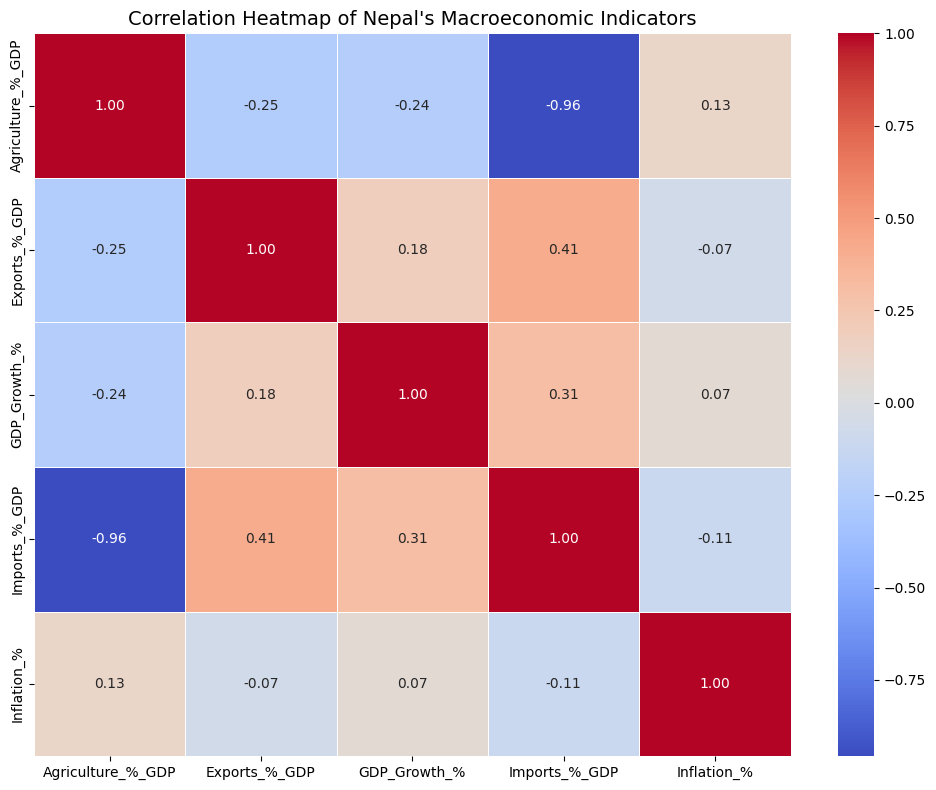

In [122]:
plt.figure(figsize=(10, 8))
correlation_matrix = df_clean.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Nepal's Macroeconomic Indicators", fontsize=14)
plt.tight_layout()

In [123]:
df_clean['Net_Exports_%_GDP'] = df_clean['Exports_%_GDP'] - df_clean['Imports_%_GDP']

In [124]:
df_clean['GDP_Growth_5yr_MA'] = df_clean['GDP_Growth_%'].rolling(window=5).mean()
df_clean['GDP_Growth_5yr_MA'] = df_clean['GDP_Growth_5yr_MA'].bfill()

In [125]:
df_clean[['Net_Exports_%_GDP', 'GDP_Growth_5yr_MA']].head()

,Net_Exports_%_GDP,GDP_Growth_5yr_MA
Year,,
1961,-6.158515,2.408591
1962,-6.158515,2.408591
1963,-6.158515,2.408591
1964,-6.158515,2.408591
1965,-6.158515,2.408591


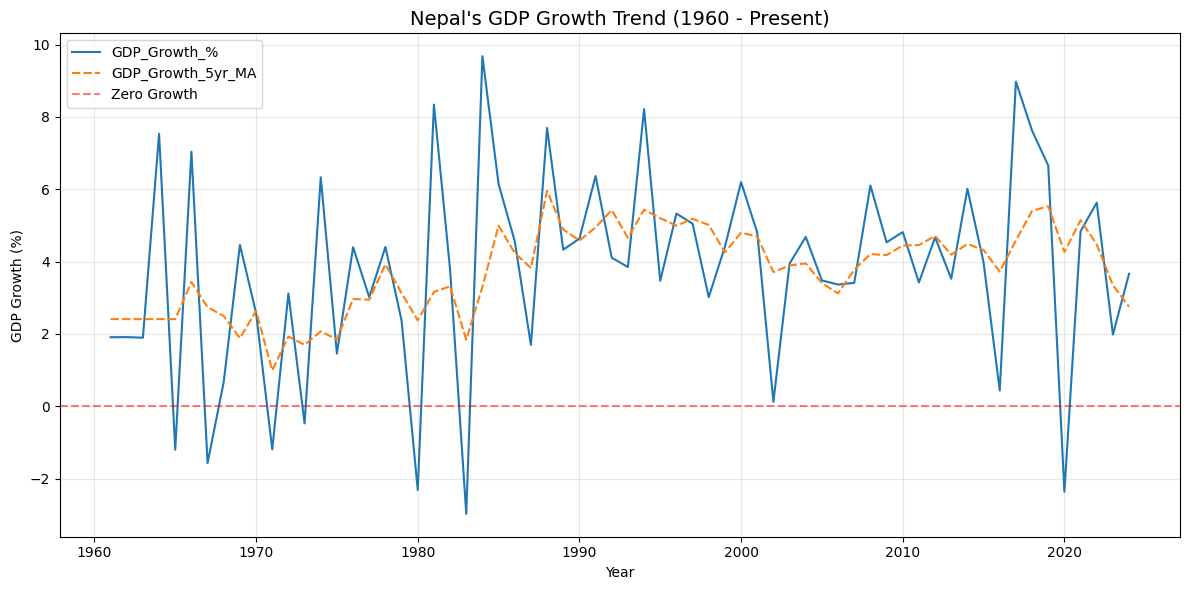

In [126]:
# Plot 1: GDP Growth Trend
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_clean[['GDP_Growth_%', 'GDP_Growth_5yr_MA']])
plt.axhline(0, color='red', linestyle='--', alpha=0.5, label='Zero Growth')
plt.title("Nepal's GDP Growth Trend (1960 - Present)", fontsize=14)
plt.xlabel("Year")
plt.ylabel("GDP Growth (%)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()


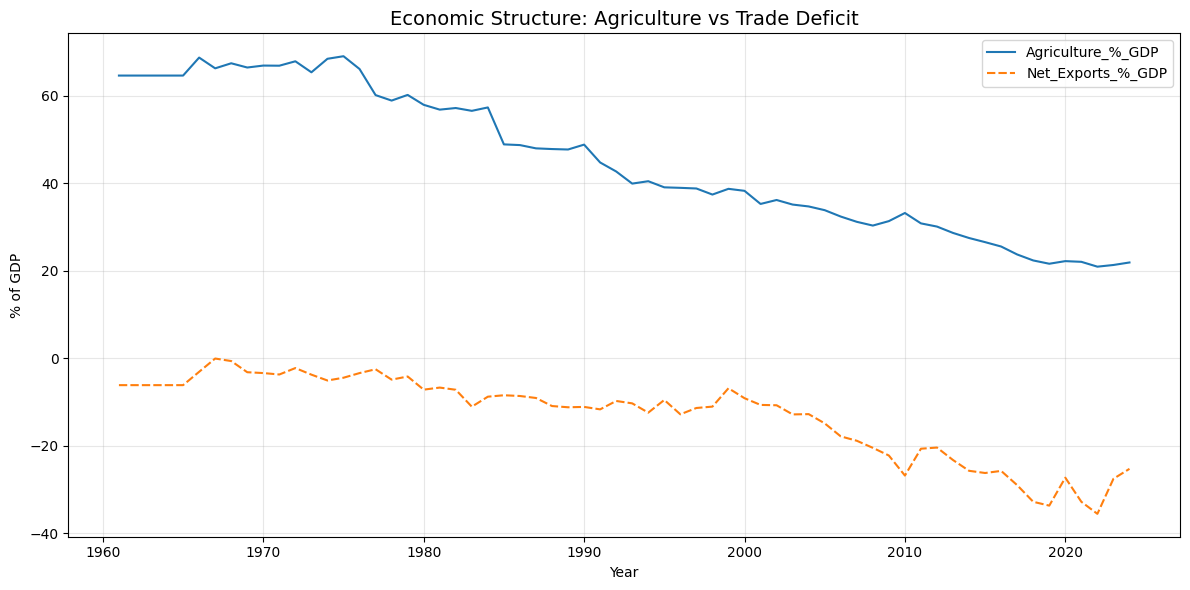

In [127]:
# Plot 2: Agriculture vs Net Exports (Structural Shift)
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_clean[['Agriculture_%_GDP','Net_Exports_%_GDP']])

plt.title("Economic Structure: Agriculture vs Trade Deficit", fontsize=14)
plt.xlabel("Year")
plt.ylabel("% of GDP")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

In [ ]:
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE


df_ml = df_clean.copy()


df_ml['Target_Is_Recession'] = (df_ml['GDP_Growth_%'] < 0).astype(int)

feature_cols = ['Agriculture_%_GDP', 'Exports_%_GDP', 'Imports_%_GDP', 
                'Inflation_%', 'Net_Exports_%_GDP', 'GDP_Growth_5yr_MA']

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(df_ml[feature_cols]), 
                        columns=[f"{col}_Scaled" for col in feature_cols])
y = df_ml['Target_Is_Recession'].values


In [ ]:
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)


In [ ]:
df_ml_ready = X_resampled.copy()
df_ml_ready['Target_Is_Recession'] = y_resampled




In [ ]:
df_ml_ready.to_csv("nepal_macro_ml_ready.csv", index=False)